In [ ]:
# @title Step 1: Networks Upload

# ============================================================
# 0) UPLOAD AND VERIFY REQUIRED NETWORK FILES
# ============================================================
# Run this cell before running the graph code.
# This cell works in Google Colab and also gives a fallback for Jupyter/local use.

import os
from pathlib import Path


REQUIRED_NETWORK_FILES = [
    "nsclc_31_nodes.txt",
    "nsclc_29_nodes.txt",
    "nsclc_14_nodes.txt",
    "nsclc_9_nodes.txt",
    "nsclc_9_nodes_fit.txt",
]

REFERENCE_FILE = "nsclc_31_nodes.txt"


def print_required_files():
    print("Required files:")
    for file_name in REQUIRED_NETWORK_FILES:
        print(f"  - {file_name}")


def check_required_files(folder="."):
    """
    Check whether all required files exist in the selected folder.
    """

    folder = Path(folder)

    existing_files = []
    missing_files = []

    for file_name in REQUIRED_NETWORK_FILES:
        file_path = folder / file_name

        if file_path.exists():
            existing_files.append(file_name)
        else:
            missing_files.append(file_name)

    return existing_files, missing_files


def verify_required_files(folder="."):
    """
    Print a clear summary of uploaded / missing files.
    """

    existing_files, missing_files = check_required_files(folder)

    print("\nFile check:")
    print("-" * 50)

    for file_name in existing_files:
        print(f"OK      {file_name}")

    for file_name in missing_files:
        print(f"MISSING {file_name}")

    print("-" * 50)

    if missing_files:
        print("\nSome files are missing.")
        print("Please upload the missing files and run this cell again.")
        return False

    print("\nAll required files were found.")
    print("You can now run the graph code.")
    return True


def upload_files_colab():
    """
    Upload required files in Google Colab.
    """

    from google.colab import files

    print("Please upload the following files:")
    print_required_files()

    print("\nClick 'Choose Files' and select all required .txt files.")
    uploaded = files.upload()

    for uploaded_name, content in uploaded.items():
        uploaded_path = Path(uploaded_name)

        if uploaded_path.name in REQUIRED_NETWORK_FILES:
            with open(uploaded_path.name, "wb") as output_file:
                output_file.write(content)

            print(f"Uploaded: {uploaded_path.name}")

        else:
            print(f"Warning: '{uploaded_path.name}' is not one of the required files.")

    return verify_required_files(".")


def upload_files_jupyter():
    """
    Interactive upload widget for Jupyter Notebook / JupyterLab.
    """

    try:
        import ipywidgets as widgets
        from IPython.display import display
    except Exception:
        print("ipywidgets is not available.")
        print("Please place the required files in the same folder as this notebook.")
        print_required_files()
        return verify_required_files(".")

    print("Please upload exactly these files:")
    print_required_files()

    uploader = widgets.FileUpload(
        accept=".txt",
        multiple=True,
        description="Upload networks"
    )

    button = widgets.Button(
        description="Save and verify files",
        button_style="success"
    )

    output = widgets.Output()

    def save_uploaded_files(_):
        with output:
            output.clear_output()

            if not uploader.value:
                print("No files were uploaded.")
                return

            uploaded_items = uploader.value

            # ipywidgets 7 returns a dict
            # ipywidgets 8 returns a tuple/list of dictionaries
            if isinstance(uploaded_items, dict):
                uploaded_items = uploaded_items.values()

            for item in uploaded_items:
                file_name = item["name"]

                if file_name not in REQUIRED_NETWORK_FILES:
                    print(f"Warning: '{file_name}' is not one of the required files.")
                    continue

                content = item["content"]

                with open(file_name, "wb") as output_file:
                    output_file.write(content)

                print(f"Uploaded: {file_name}")

            verify_required_files(".")

    button.on_click(save_uploaded_files)

    display(uploader)
    display(button)
    display(output)


def run_upload_interface():
    """
    Detect whether the code is running in Colab or local/Jupyter.
    """

    print("=" * 60)
    print("NETWORK FILE UPLOAD")
    print("=" * 60)

    existing_files, missing_files = check_required_files(".")

    if not missing_files:
        print("All required files are already available.")
        verify_required_files(".")
        return

    try:
        import google.colab  # noqa: F401
        upload_files_colab()

    except Exception:
        print("Google Colab was not detected.")
        print("Using Jupyter/local upload interface instead.\n")
        upload_files_jupyter()


run_upload_interface()

NETWORK FILE UPLOAD
Please upload the following files:
Required files:
  - nsclc_31_nodes.txt
  - nsclc_29_nodes.txt
  - nsclc_14_nodes.txt
  - nsclc_9_nodes.txt
  - nsclc_9_nodes_fit.txt

Click 'Choose Files' and select all required .txt files.


Saving nsclc_9_nodes_fit.txt to nsclc_9_nodes_fit.txt
Saving nsclc_9_nodes.txt to nsclc_9_nodes.txt
Saving nsclc_14_nodes.txt to nsclc_14_nodes.txt
Saving nsclc_29_nodes.txt to nsclc_29_nodes.txt
Saving nsclc_31_nodes.txt to nsclc_31_nodes.txt
Uploaded: nsclc_9_nodes_fit.txt
Uploaded: nsclc_9_nodes.txt
Uploaded: nsclc_14_nodes.txt
Uploaded: nsclc_29_nodes.txt
Uploaded: nsclc_31_nodes.txt

File check:
--------------------------------------------------
OK      nsclc_31_nodes.txt
OK      nsclc_29_nodes.txt
OK      nsclc_14_nodes.txt
OK      nsclc_9_nodes.txt
OK      nsclc_9_nodes_fit.txt
--------------------------------------------------

All required files were found.
You can now run the graph code.


Reference network: nsclc_31_nodes
Nodes in reference network: 31
Nodes in union graph: 31


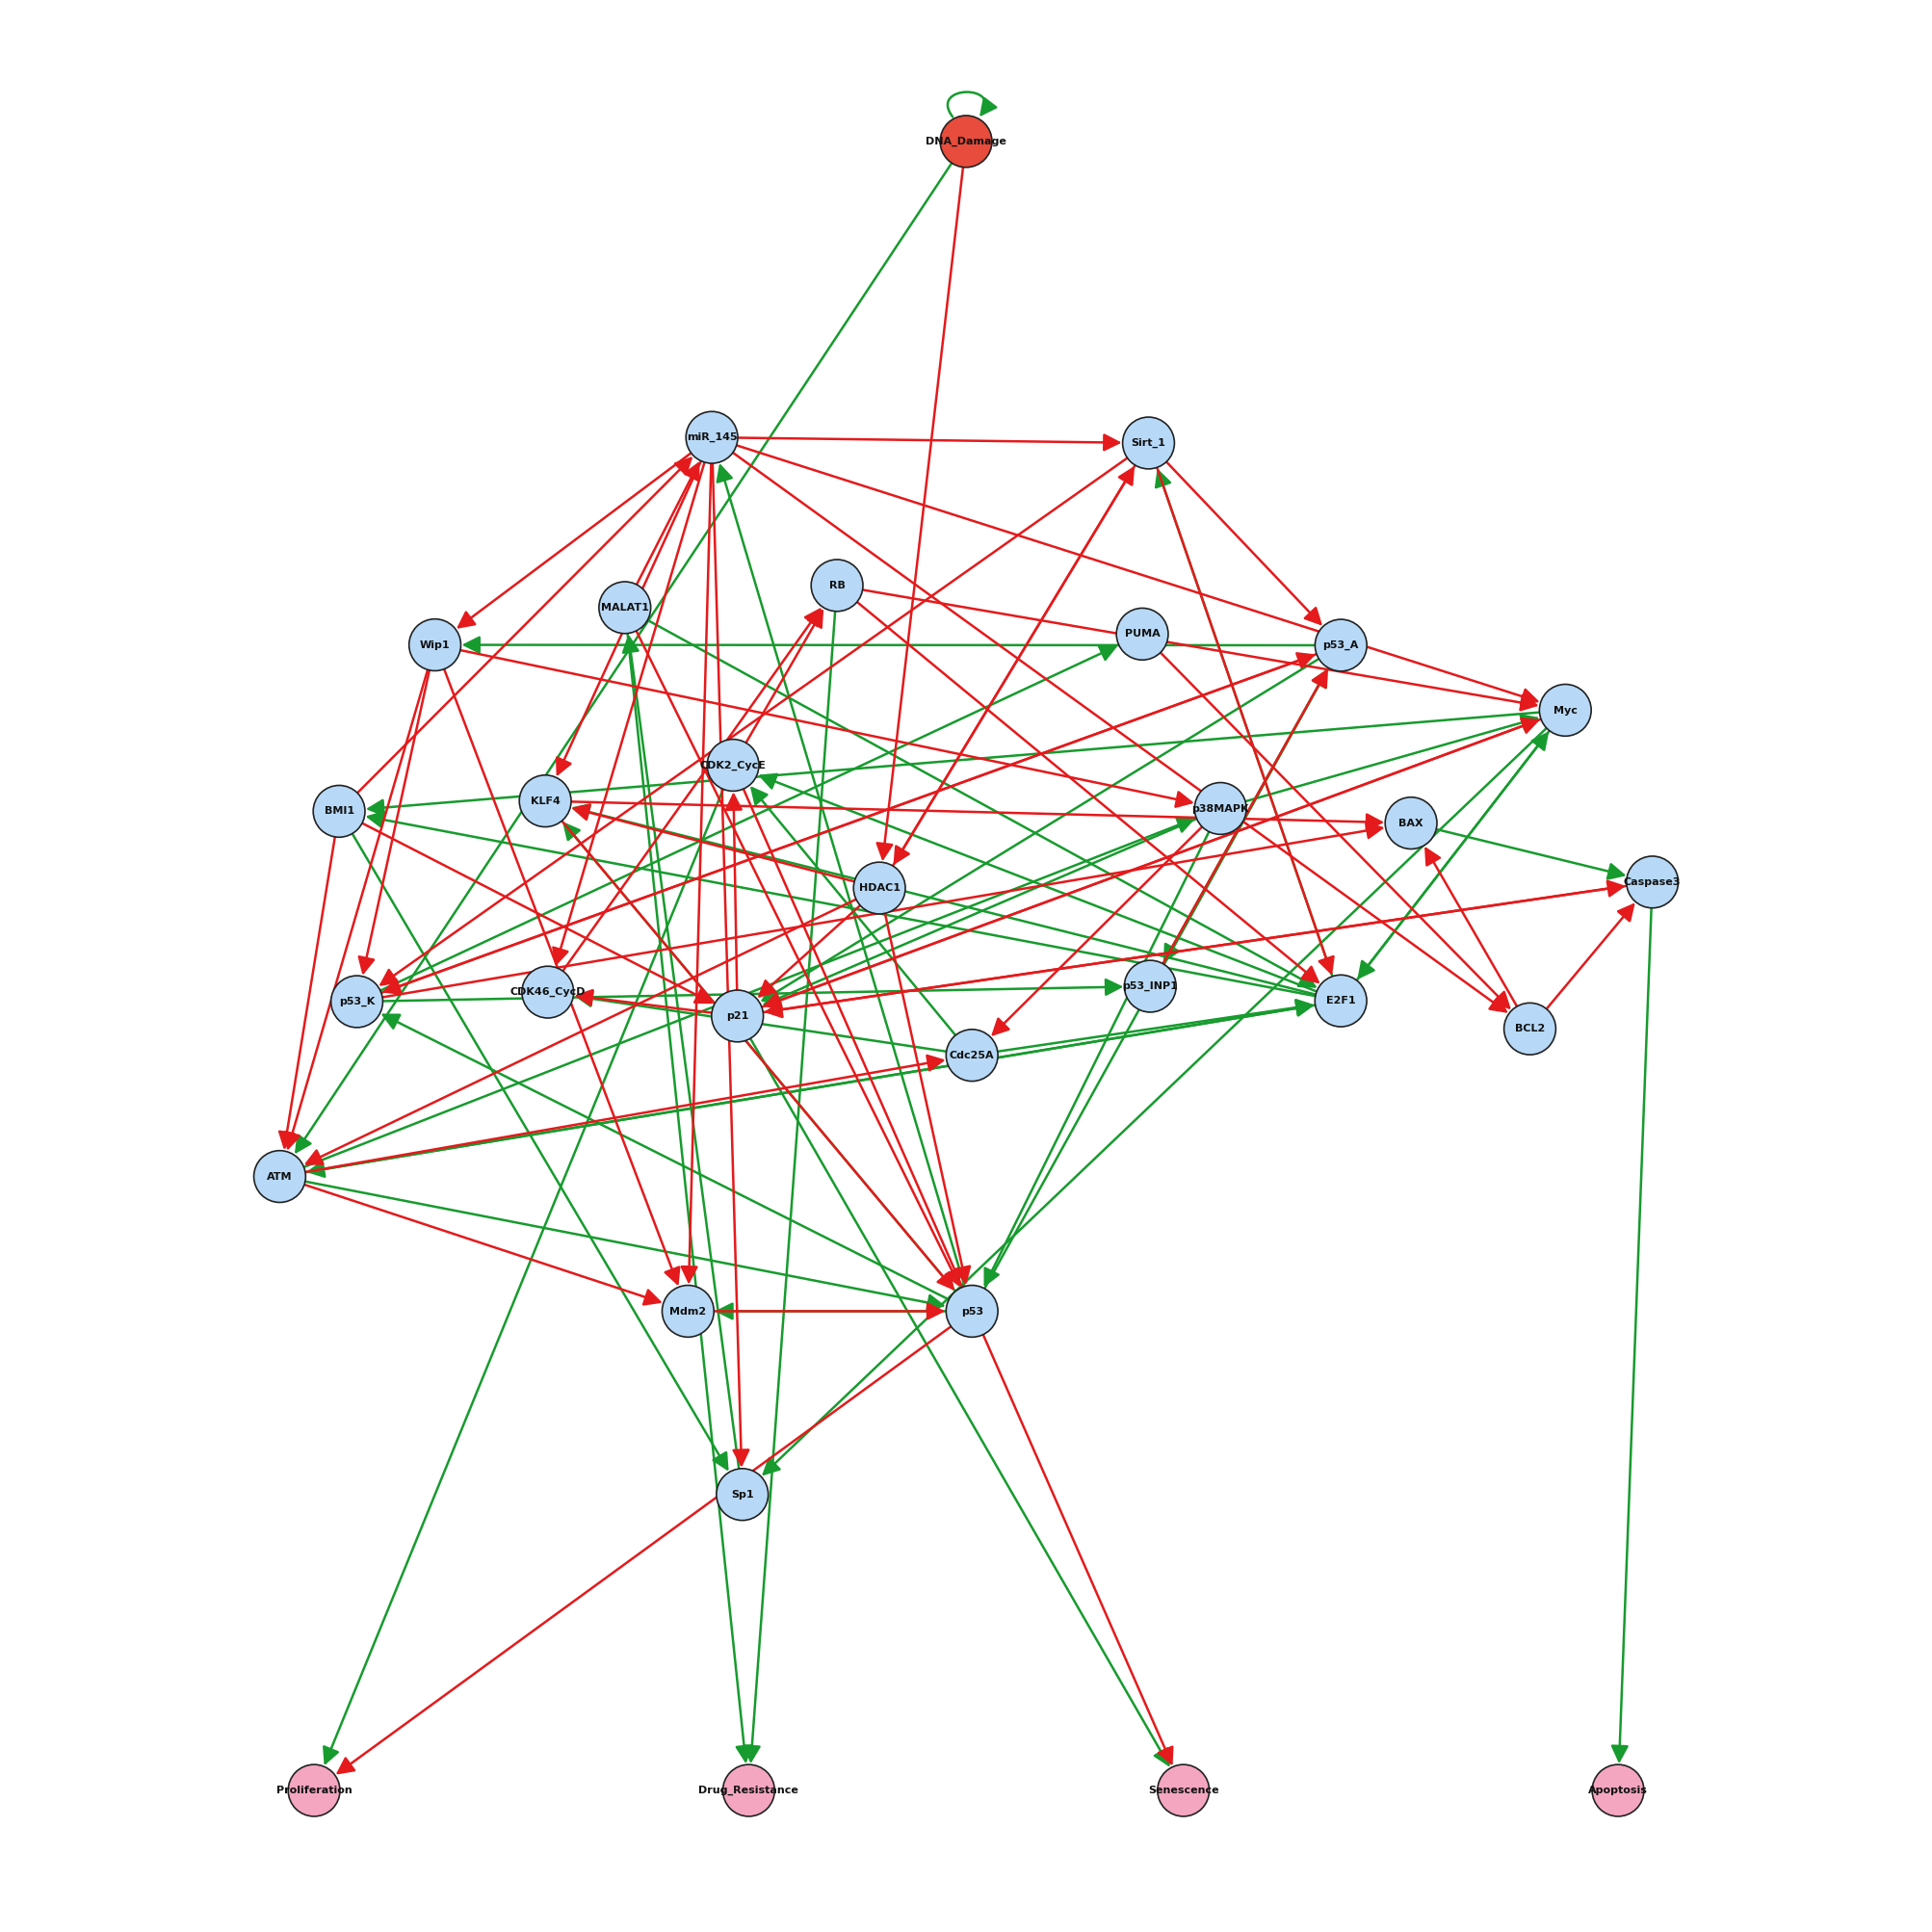

Saved: NSCLC_fixed_layout_no_graphviz/nsclc_31_nodes_fixed_layout_no_graphviz.png
Saved: NSCLC_fixed_layout_no_graphviz/nsclc_31_nodes_fixed_layout_no_graphviz.svg


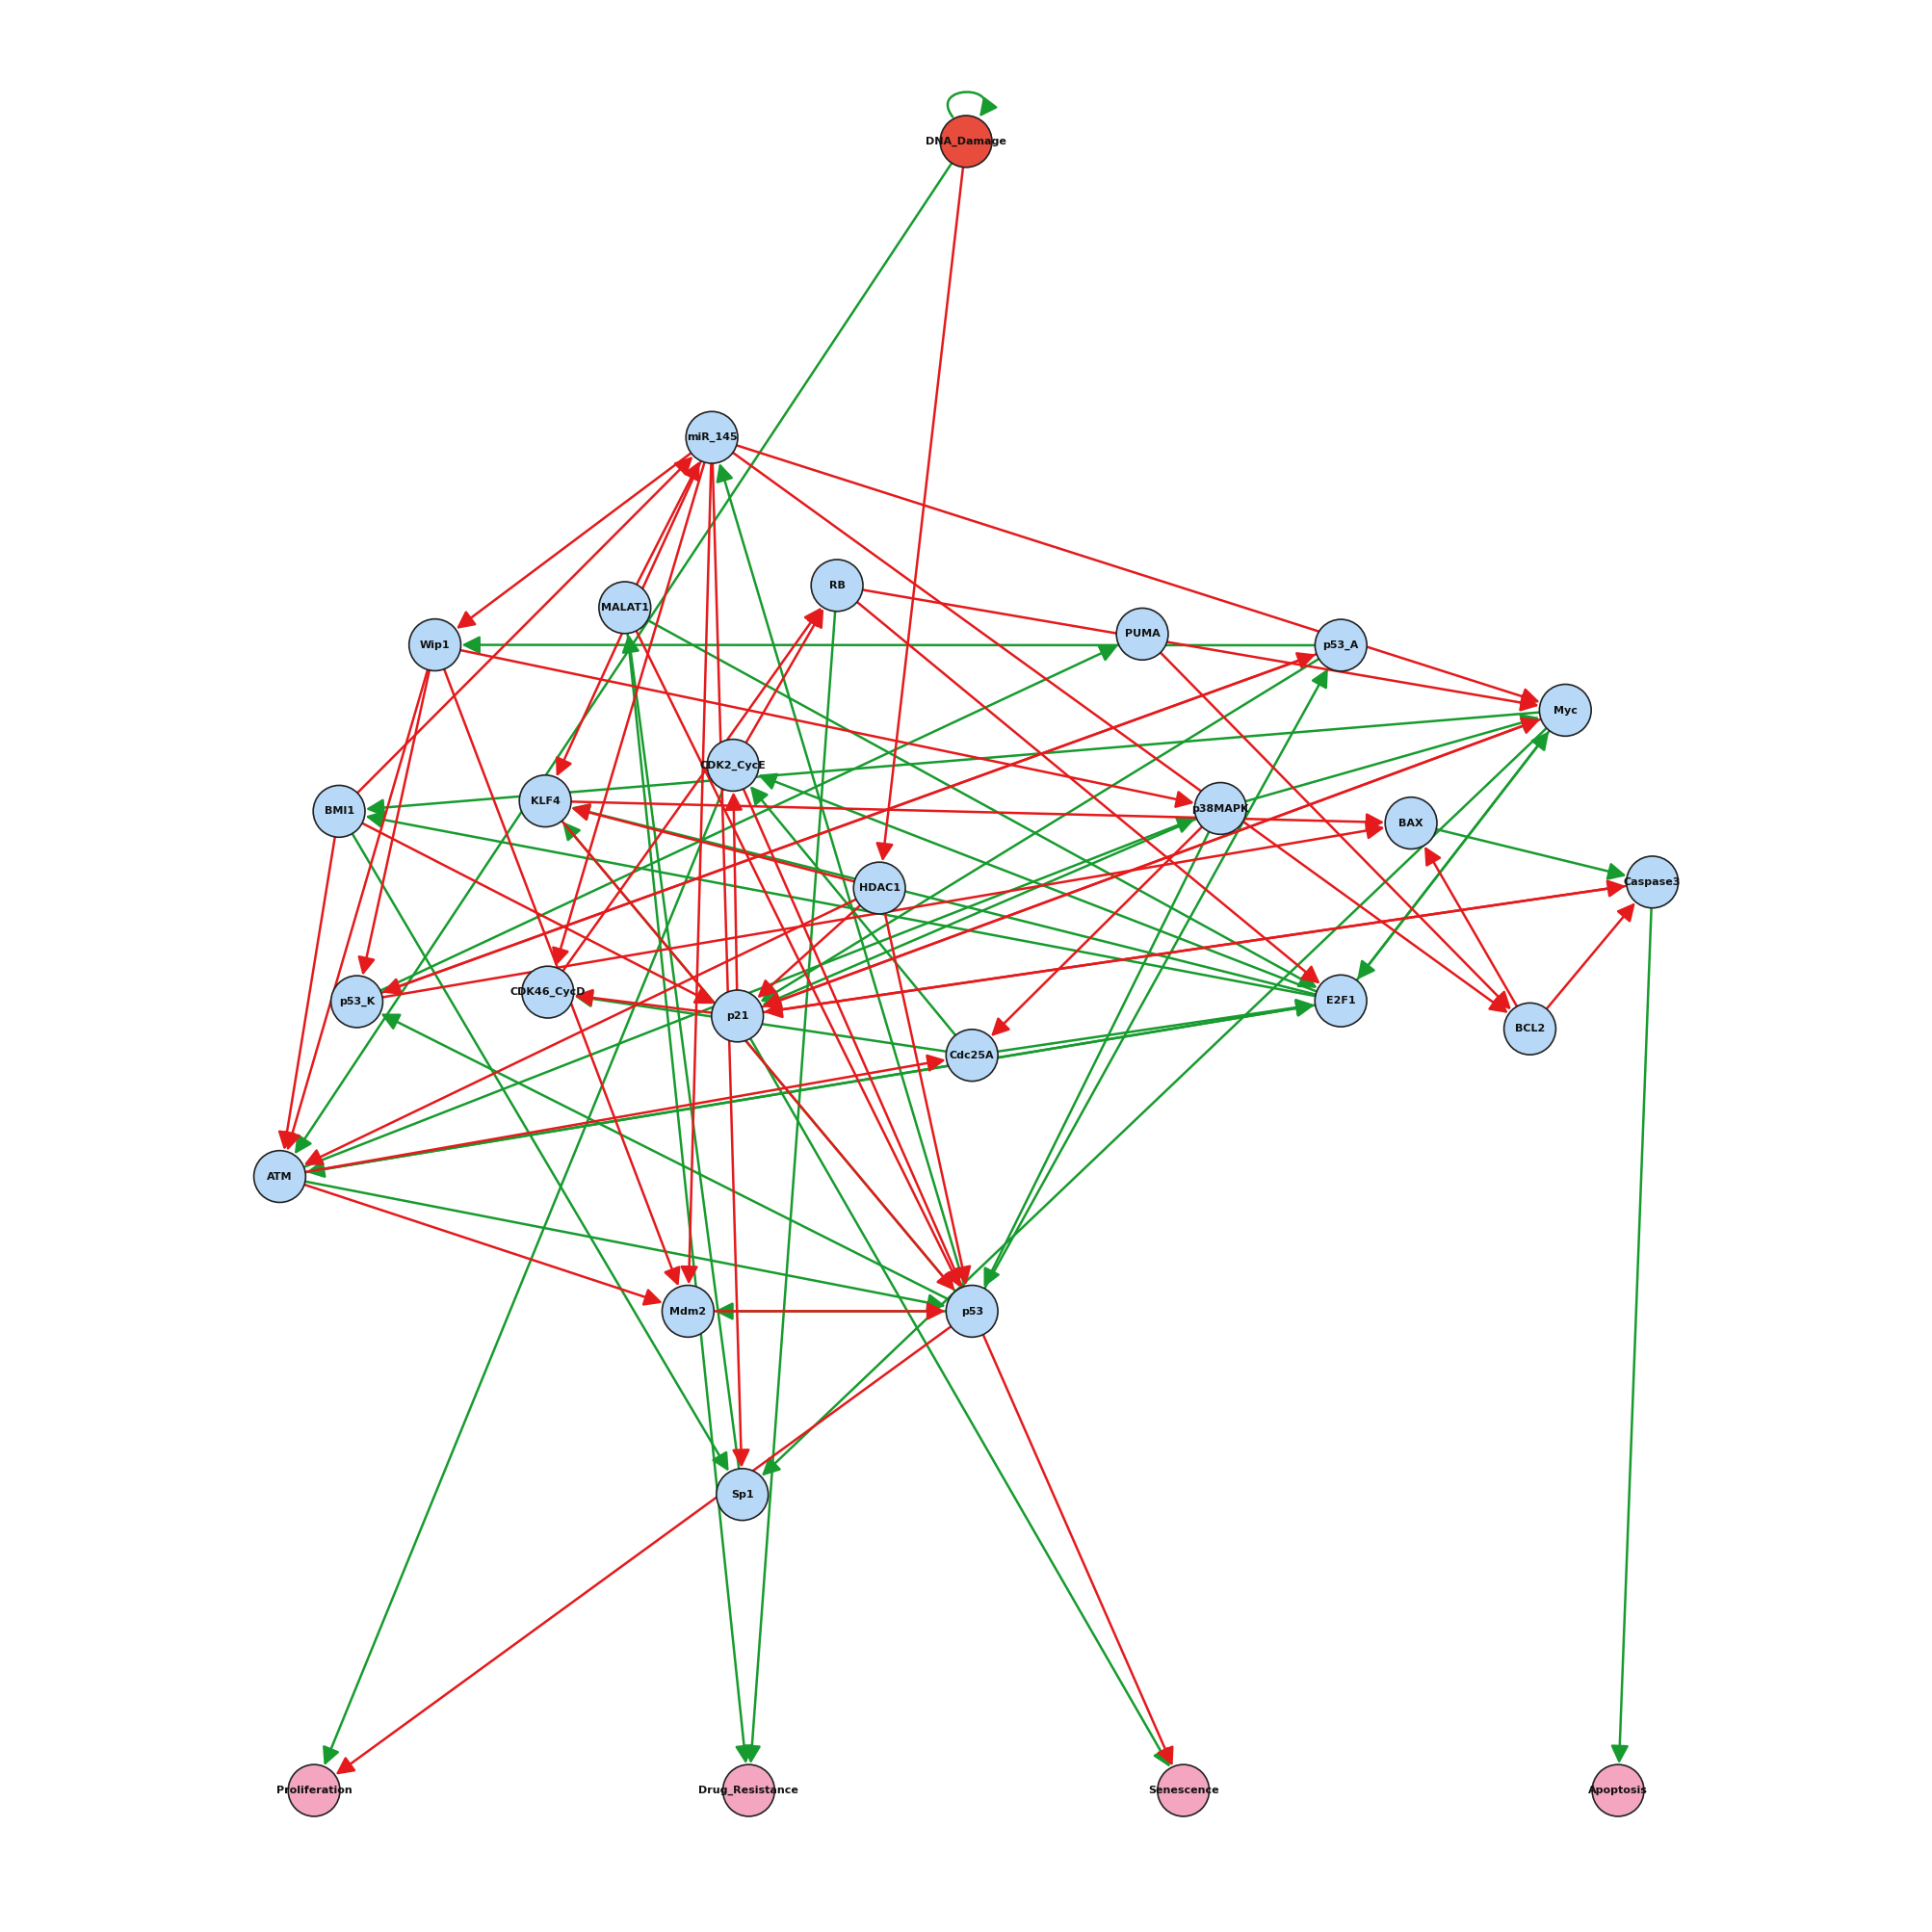

Saved: NSCLC_fixed_layout_no_graphviz/nsclc_29_nodes_fixed_layout_no_graphviz.png
Saved: NSCLC_fixed_layout_no_graphviz/nsclc_29_nodes_fixed_layout_no_graphviz.svg


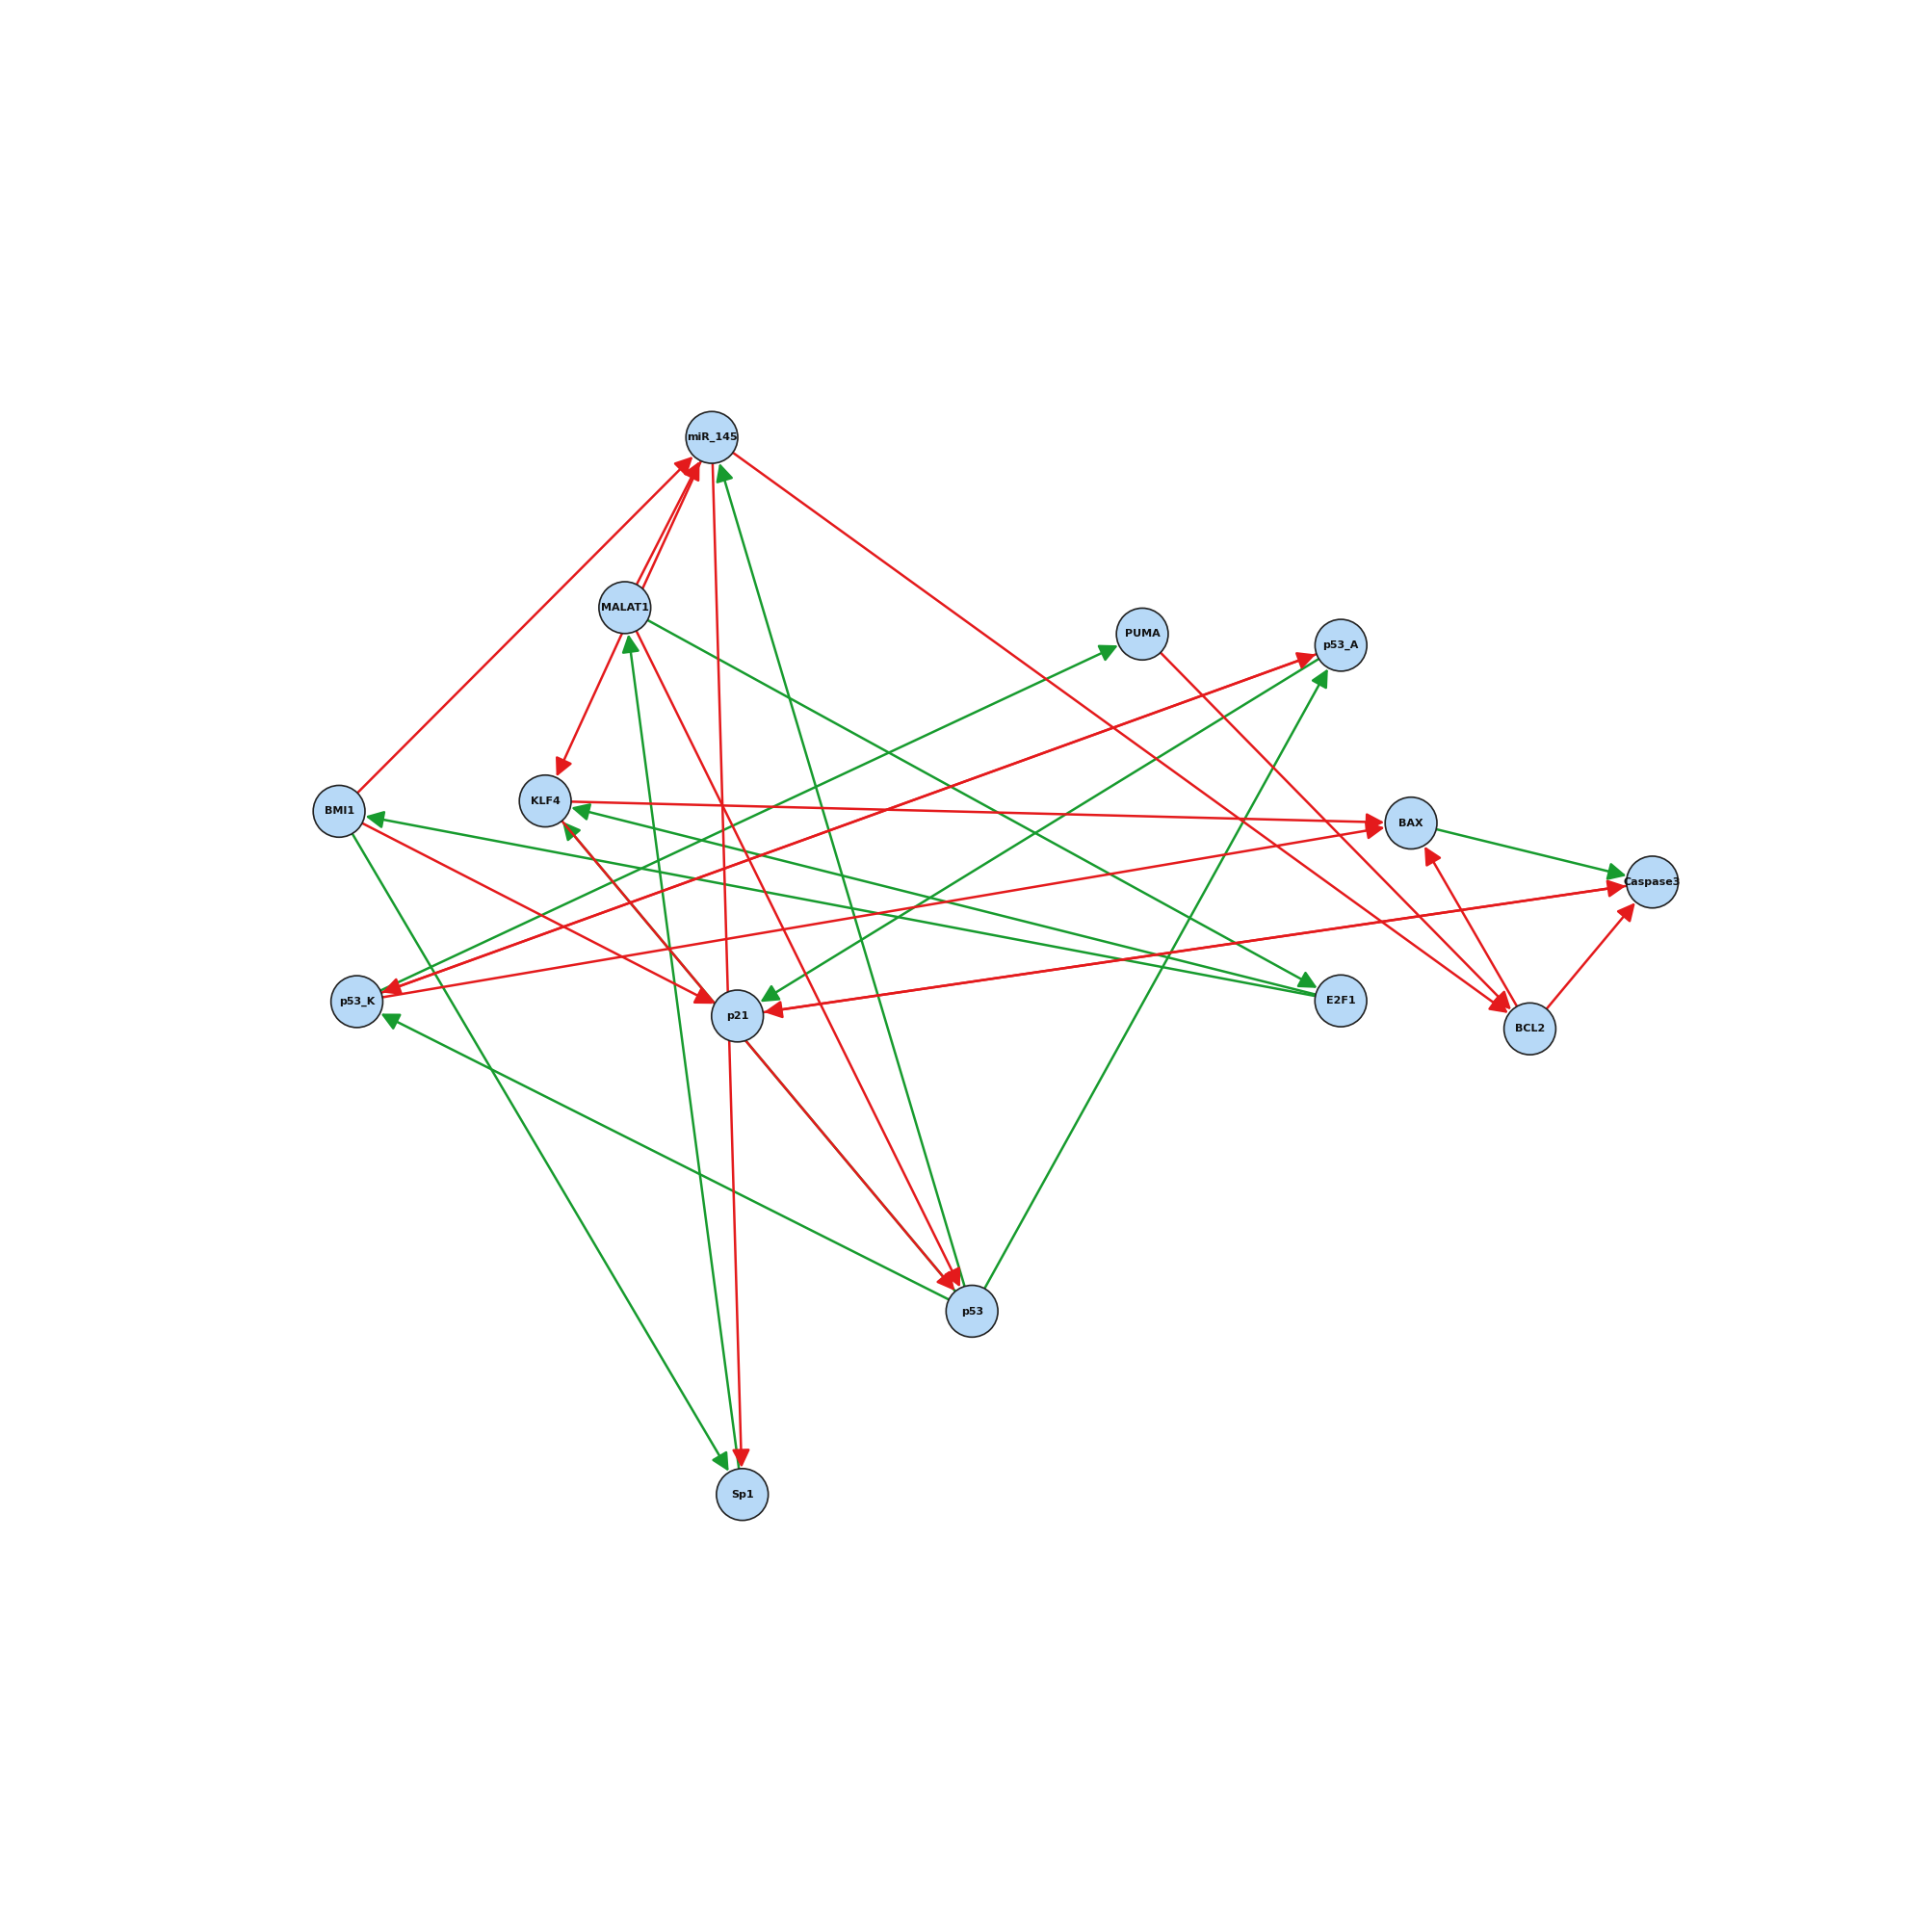

Saved: NSCLC_fixed_layout_no_graphviz/nsclc_14_nodes_fixed_layout_no_graphviz.png
Saved: NSCLC_fixed_layout_no_graphviz/nsclc_14_nodes_fixed_layout_no_graphviz.svg


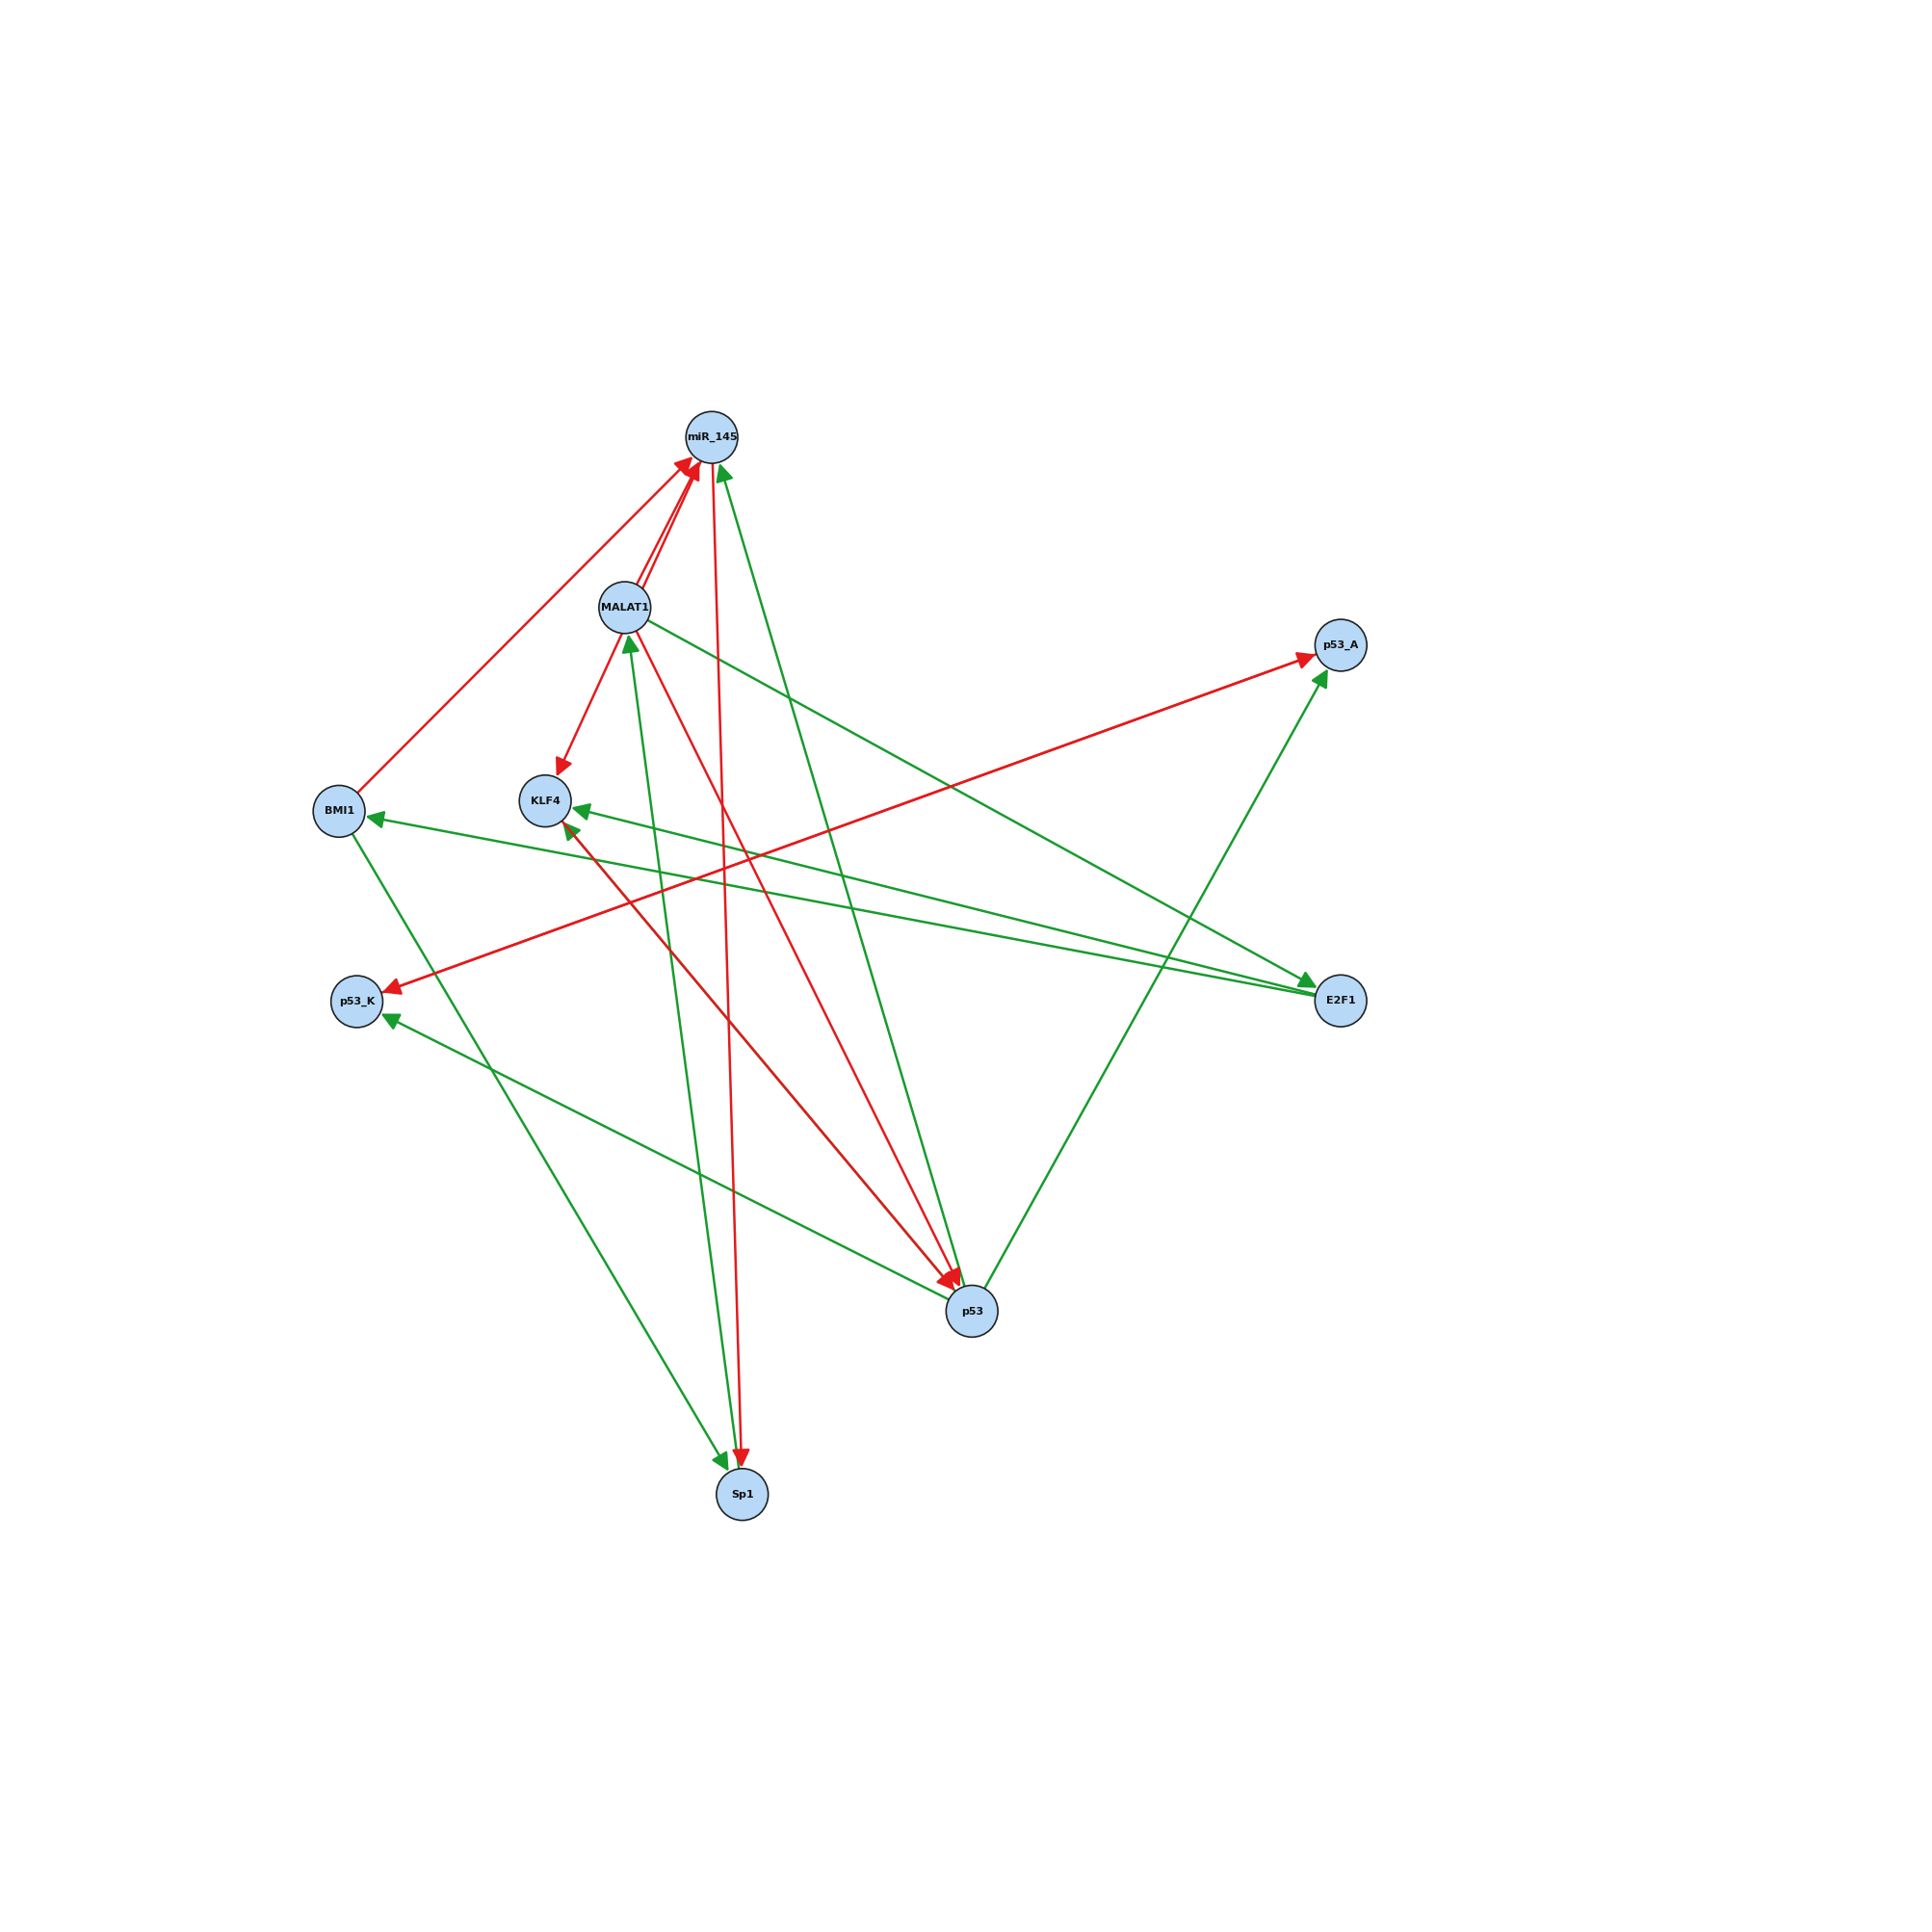

Saved: NSCLC_fixed_layout_no_graphviz/nsclc_9_nodes_fixed_layout_no_graphviz.png
Saved: NSCLC_fixed_layout_no_graphviz/nsclc_9_nodes_fixed_layout_no_graphviz.svg


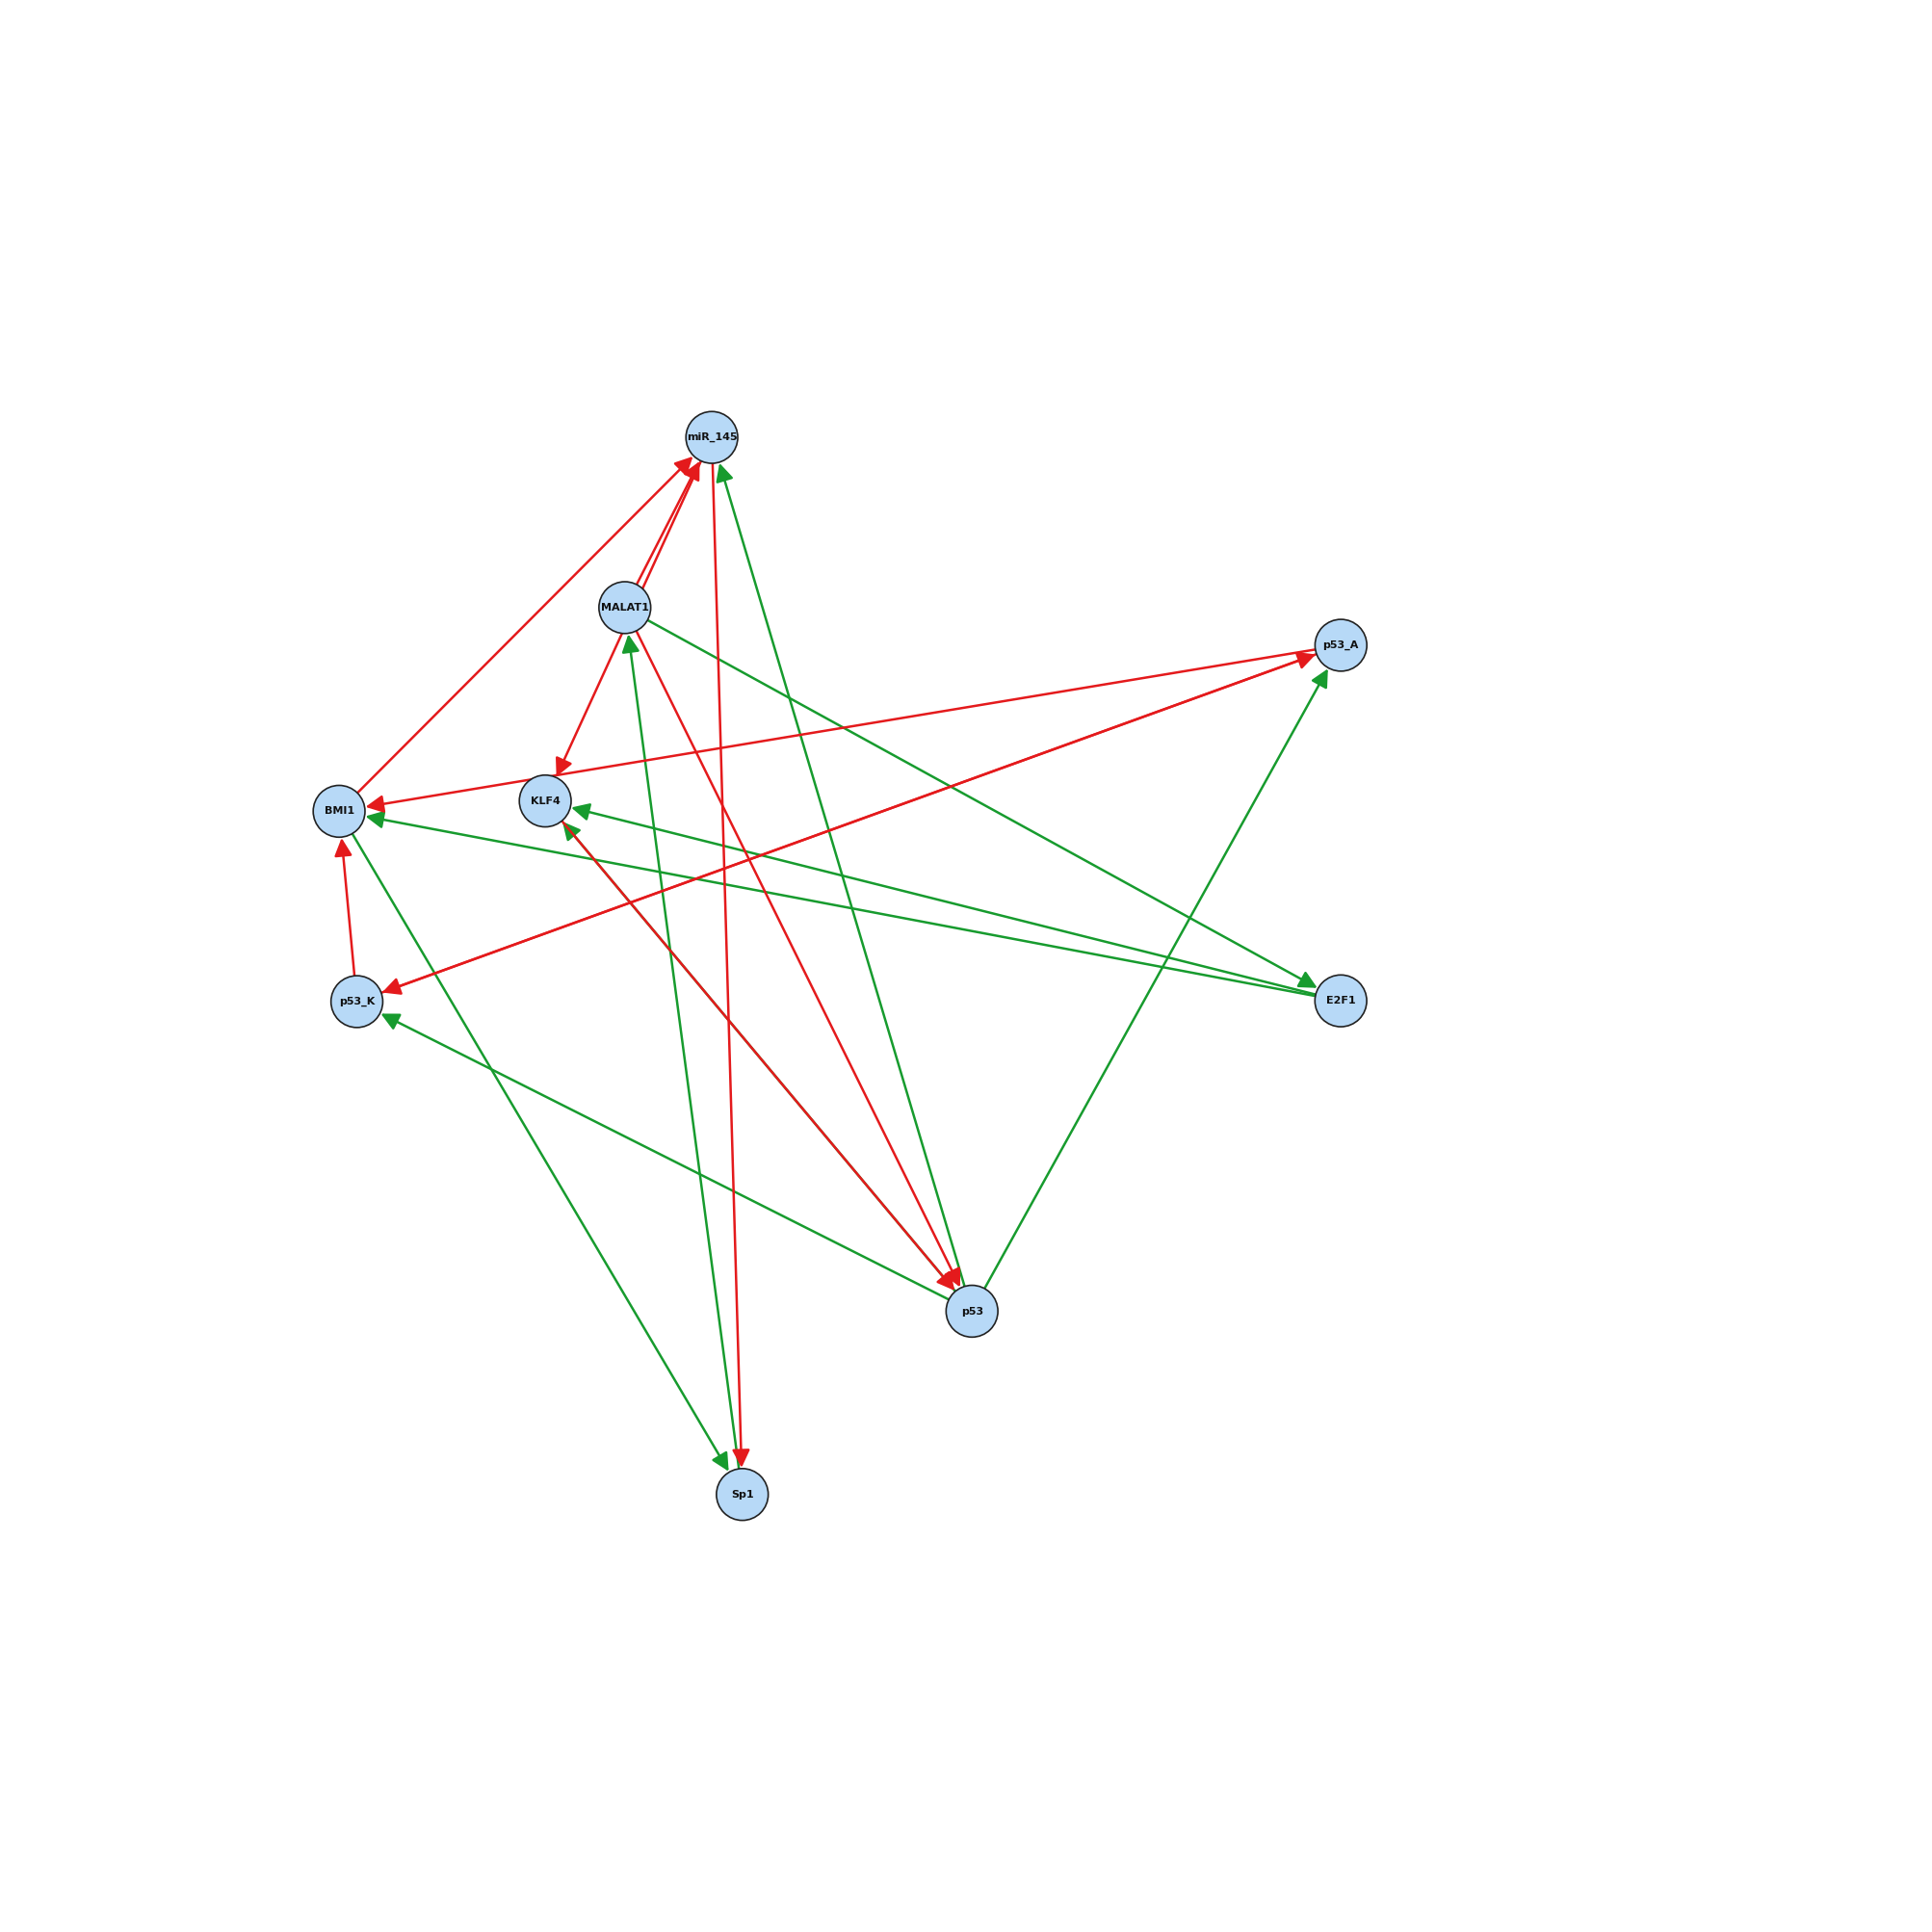

Saved: NSCLC_fixed_layout_no_graphviz/nsclc_9_nodes_fit_fixed_layout_no_graphviz.png
Saved: NSCLC_fixed_layout_no_graphviz/nsclc_9_nodes_fit_fixed_layout_no_graphviz.svg


In [ ]:
# @title Step 2: Network Graphing

import os
import re
import math
from pathlib import Path
from itertools import combinations

import networkx as nx
import matplotlib.pyplot as plt
from matplotlib.path import Path as MplPath
from matplotlib.patches import FancyArrowPatch

# ============================================================
# 1) GENERAL CONFIGURATION
# ============================================================

NETWORK_FILES = [
    "nsclc_31_nodes.txt",
    "nsclc_29_nodes.txt",
    "nsclc_14_nodes.txt",
    "nsclc_9_nodes.txt",
    "nsclc_9_nodes_fit.txt",
]

REFERENCE_FILE = "nsclc_31_nodes.txt"

OUTPUT_DIR = "NSCLC_fixed_layout_no_graphviz"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# ------------------------------------------------------------
# Figure format
# ------------------------------------------------------------

FIGSIZE = (20, 20)   # width, height
DPI = 300

# ------------------------------------------------------------
# Global layout
# ------------------------------------------------------------

SEED = 33
SPRING_K = 2.8
SPRING_ITERATIONS = 3000
SPRING_SCALE = 1800

MIN_NODE_DISTANCE = 350

# ------------------------------------------------------------
# Visual style
# ------------------------------------------------------------

NODE_SIZE = 1500
FONT_SIZE = 8

EDGE_WIDTH = 1.8

# More visible arrows
ARROW_SIZE = 28
ARROW_STYLE = "-|>"

# Margins so arrowheads are not hidden under nodes
SOURCE_MARGIN = 8
TARGET_MARGIN = 20


# Show removed nodes as gray reference nodes
SHOW_REMOVED_NODES_AS_GHOSTS = False

# ------------------------------------------------------------
# Special nodes
# ------------------------------------------------------------

TOP_NODE = "DNA_Damage"

BOTTOM_NODES = [
    "Proliferation",
    "Drug_Resistance",
    "Senescence",
    "Apoptosis",
]

SPECIAL_NODES = [TOP_NODE] + BOTTOM_NODES

SPECIAL_NODE_COLORS = {
    "DNA_Damage": "#e74c3c",
    "Proliferation": "#f4a6c1",
    "Drug_Resistance": "#f4a6c1",
    "Senescence": "#f4a6c1",
    "Apoptosis": "#f4a6c1",
}

DEFAULT_NODE_COLOR = "#b7d9f7"

POSITIVE_EDGE_COLOR = "#179b2e"
NEGATIVE_EDGE_COLOR = "#e41a1c"

# Negative edges as one solid red line
NEGATIVE_EDGE_STYLE = "solid"

# Straight edges
EDGE_CONNECTION_STYLE = "arc3,rad=0.0"


# ============================================================
# 2) SELF-LOOP CONTROL
# ============================================================
# Modify these values to change the self-loop size.
# Lower value = smaller loop.
# Higher value = larger loop.

SELF_LOOP_RX = 70
SELF_LOOP_RY = 105
SELF_LOOP_OFFSET_Y = 45

# ============================================================
# 3) READ NETWORK FILES
# ============================================================

token_pattern = re.compile(r"(!)?\b([A-Za-z0-9_]+)\b")

def read_rules_as_graph(file_path):

    graph = nx.DiGraph()

    with open(file_path, "r", encoding="utf-8-sig") as file:
        for line in file:
            line = line.strip()

            if not line:
                continue

            if line.lower().startswith("targets"):
                continue

            target, expression = line.split(",", 1)

            target = target.strip()
            expression = expression.strip()

            graph.add_node(target)

            for negation, factor in token_pattern.findall(expression):
                if factor.lower() in {"and", "or", "not"}:
                    continue

                relation = "negative" if negation else "positive"

                graph.add_edge(
                    factor,
                    target,
                    relation=relation,
                )

    return graph


def resolve_existing_files(files):

    resolved_files = []

    for file_name in files:
        candidates = [
            Path(file_name),
            Path.cwd() / file_name,
            Path("/mnt/data") / file_name,
        ]

        found_file = next((path for path in candidates if path.exists()), None)

        if found_file is None:
            print(f"Warning: file not found and skipped: {file_name}")
        else:
            resolved_files.append(str(found_file))

    return resolved_files

def build_union_graph(graphs):

    union_graph = nx.DiGraph()

    for graph in graphs.values():
        union_graph.add_nodes_from(graph.nodes())
        union_graph.add_edges_from(graph.edges(data=True))

    return union_graph

# ============================================================
# 4) GLOBAL LAYOUT WITHOUT GRAPHVIZ
# ============================================================

def initial_anchor_positions(graph):

    initial_positions = {}

    if TOP_NODE in graph:
        initial_positions[TOP_NODE] = (0.0, 1200.0)

    bottom_x_positions = [-1200.0, -400.0, 400.0, 1200.0]

    for node, x_value in zip(BOTTOM_NODES, bottom_x_positions):
        if node in graph:
            initial_positions[node] = (x_value, -1200.0)

    return initial_positions

def compute_base_layout(graph):

    initial_positions = initial_anchor_positions(graph)

    fixed_nodes = [
        node for node in SPECIAL_NODES
        if node in graph and node in initial_positions
    ]

    if fixed_nodes:
        layout = nx.spring_layout(
            graph,
            pos=initial_positions,
            fixed=fixed_nodes,
            seed=SEED,
            k=SPRING_K,
            iterations=SPRING_ITERATIONS,
            scale=SPRING_SCALE,
        )
    else:
        layout = nx.spring_layout(
            graph,
            seed=SEED,
            k=SPRING_K,
            iterations=SPRING_ITERATIONS,
            scale=SPRING_SCALE,
        )

    return {
        node: (float(x), float(y))
        for node, (x, y) in layout.items()
    }

def align_special_nodes(
    positions,
    top_node=TOP_NODE,
    bottom_nodes=BOTTOM_NODES,
):

    positions = dict(positions)

    special_present = {
        node for node in [top_node] + bottom_nodes
        if node in positions
    }

    core_nodes = [
        node for node in positions
        if node not in special_present
    ]

    if not core_nodes:
        return positions

    x_values = [positions[node][0] for node in core_nodes]
    y_values = [positions[node][1] for node in core_nodes]

    min_x, max_x = min(x_values), max(x_values)
    min_y, max_y = min(y_values), max(y_values)

    width = max(max_x - min_x, 1.0)
    height = max(max_y - min_y, 1.0)

    center_x = (min_x + max_x) / 2

    vertical_gap = max(0.28 * height, 420)

    top_y = max_y + vertical_gap
    bottom_y = min_y - vertical_gap

    if top_node in positions:
        positions[top_node] = (center_x, top_y)

    present_bottom_nodes = [
        node for node in bottom_nodes
        if node in positions
    ]

    if present_bottom_nodes:
        span = max(
            0.95 * width,
            520 * (len(present_bottom_nodes) - 1),
        )

        if len(present_bottom_nodes) == 1:
            bottom_x_values = [center_x]
        else:
            step = span / (len(present_bottom_nodes) - 1)

            bottom_x_values = [
                center_x - span / 2 + i * step
                for i in range(len(present_bottom_nodes))
            ]

        for node, x_value in zip(present_bottom_nodes, bottom_x_values):
            positions[node] = (x_value, bottom_y)

    return positions


def separate_overlapping_nodes(
    positions,
    fixed_nodes=None,
    min_distance=180,
    iterations=800,
):

    fixed_nodes = set(fixed_nodes or [])

    positions = {
        node: [float(x), float(y)]
        for node, (x, y) in positions.items()
    }

    nodes = list(positions)

    for _ in range(iterations):
        max_push = 0.0

        for node_a, node_b in combinations(nodes, 2):
            ax, ay = positions[node_a]
            bx, by = positions[node_b]

            dx = bx - ax
            dy = by - ay

            distance = math.hypot(dx, dy)

            if distance >= min_distance:
                continue

            if distance < 1e-9:
                dx, dy, distance = 1.0, 0.0, 1.0

            unit_x = dx / distance
            unit_y = dy / distance

            push = (min_distance - distance) / 2.0

            node_a_is_fixed = node_a in fixed_nodes
            node_b_is_fixed = node_b in fixed_nodes

            if node_a_is_fixed and node_b_is_fixed:
                continue

            elif node_a_is_fixed:
                positions[node_b][0] += 2 * push * unit_x
                positions[node_b][1] += 2 * push * unit_y
                max_push = max(max_push, 2 * push)

            elif node_b_is_fixed:
                positions[node_a][0] -= 2 * push * unit_x
                positions[node_a][1] -= 2 * push * unit_y
                max_push = max(max_push, 2 * push)

            else:
                positions[node_a][0] -= push * unit_x
                positions[node_a][1] -= push * unit_y

                positions[node_b][0] += push * unit_x
                positions[node_b][1] += push * unit_y

                max_push = max(max_push, push)

        if max_push < 0.01:
            break

    return {
        node: (coordinates[0], coordinates[1])
        for node, coordinates in positions.items()
    }


def compute_global_layout(union_graph):

    positions = compute_base_layout(union_graph)

    positions = align_special_nodes(positions)

    positions = separate_overlapping_nodes(
        positions,
        fixed_nodes=[
            node for node in SPECIAL_NODES
            if node in positions
        ],
        min_distance=MIN_NODE_DISTANCE,
    )

    positions = align_special_nodes(positions)

    return positions

# ============================================================
# 5) GLOBAL AXIS LIMITS
# ============================================================

def get_global_axis_limits(
    positions,
    pad_fraction=0.08,
    target_aspect=None,
):

    x_values = [coordinates[0] for coordinates in positions.values()]
    y_values = [coordinates[1] for coordinates in positions.values()]

    min_x, max_x = min(x_values), max(x_values)
    min_y, max_y = min(y_values), max(y_values)

    pad_x = max((max_x - min_x) * pad_fraction, 100)
    pad_y = max((max_y - min_y) * pad_fraction, 100)

    min_x -= pad_x
    max_x += pad_x
    min_y -= pad_y
    max_y += pad_y

    if target_aspect is not None:
        width = max_x - min_x
        height = max_y - min_y

        current_aspect = width / height

        center_x = (min_x + max_x) / 2
        center_y = (min_y + max_y) / 2

        if current_aspect < target_aspect:
            new_width = height * target_aspect

            min_x = center_x - new_width / 2
            max_x = center_x + new_width / 2

        else:
            new_height = width / target_aspect

            min_y = center_y - new_height / 2
            max_y = center_y + new_height / 2

    return (min_x, max_x), (min_y, max_y)

# ============================================================
# 6) MANUAL SELF-LOOPS WITH ARROWS
# ============================================================

def draw_self_loop(axis, node, positions, color, style="solid"):

    x, y = positions[node]

    vertices = [
        (x - 0.35 * SELF_LOOP_RX, y + SELF_LOOP_OFFSET_Y),
        (x - SELF_LOOP_RX, y + SELF_LOOP_RY),
        (x + SELF_LOOP_RX, y + SELF_LOOP_RY),
        (x + 0.35 * SELF_LOOP_RX, y + SELF_LOOP_OFFSET_Y),
    ]

    codes = [
        MplPath.MOVETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
    ]

    path = MplPath(vertices, codes)

    loop = FancyArrowPatch(
        path=path,
        arrowstyle=ARROW_STYLE,
        mutation_scale=ARROW_SIZE,
        linewidth=EDGE_WIDTH,
        color=color,
        linestyle=style,
        zorder=1,
        clip_on=False,
    )

    axis.add_patch(loop)

# ============================================================
# 7) DRAW NETWORKS
# ============================================================

def draw_network_fixed_layout(
    graph,
    global_positions,
    output_prefix,
    reference_nodes=None,
    x_limits=None,
    y_limits=None,
    show_removed_nodes=False,
):
    figure, axis = plt.subplots(figsize=FIGSIZE)

    positions = {
        node: global_positions[node]
        for node in graph.nodes()
        if node in global_positions
    }

    # --------------------------------------------------------
    # Removed nodes as gray ghost nodes
    # --------------------------------------------------------

    if show_removed_nodes and reference_nodes is not None:
        removed_nodes = sorted(
            set(reference_nodes) - set(graph.nodes())
        )

        removed_positions = {
            node: global_positions[node]
            for node in removed_nodes
            if node in global_positions
        }

        if removed_positions:
            nx.draw_networkx_nodes(
                nx.Graph(),
                removed_positions,
                nodelist=list(removed_positions.keys()),
                node_color="#eeeeee",
                edgecolors="#cccccc",
                linewidths=0.8,
                node_size=NODE_SIZE * 0.85,
                alpha=0.50,
                ax=axis,
            )

            nx.draw_networkx_labels(
                nx.Graph(),
                removed_positions,
                labels={node: node for node in removed_positions},
                font_size=max(FONT_SIZE - 1, 6),
                font_color="#aaaaaa",
                ax=axis,
            )

    # --------------------------------------------------------
    # Separate normal edges from self-loops
    # --------------------------------------------------------

    positive_edges = [
        (source, target)
        for source, target, data in graph.edges(data=True)
        if data.get("relation") == "positive" and source != target
    ]

    negative_edges = [
        (source, target)
        for source, target, data in graph.edges(data=True)
        if data.get("relation") == "negative" and source != target
    ]

    positive_self_loops = [
        (source, target)
        for source, target, data in graph.edges(data=True)
        if data.get("relation") == "positive" and source == target
    ]

    negative_self_loops = [
        (source, target)
        for source, target, data in graph.edges(data=True)
        if data.get("relation") == "negative" and source == target
    ]

    # --------------------------------------------------------
    # Positive edges
    # --------------------------------------------------------

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=positive_edges,
        edge_color=POSITIVE_EDGE_COLOR,
        arrows=True,
        arrowstyle=ARROW_STYLE,
        arrowsize=ARROW_SIZE,
        width=EDGE_WIDTH,
        style="solid",
        connectionstyle=EDGE_CONNECTION_STYLE,
        min_source_margin=SOURCE_MARGIN,
        min_target_margin=TARGET_MARGIN,
        ax=axis,
    )

    # --------------------------------------------------------
    # Negative edges
    # --------------------------------------------------------

    nx.draw_networkx_edges(
        graph,
        positions,
        edgelist=negative_edges,
        edge_color=NEGATIVE_EDGE_COLOR,
        arrows=True,
        arrowstyle=ARROW_STYLE,
        arrowsize=ARROW_SIZE,
        width=EDGE_WIDTH,
        style=NEGATIVE_EDGE_STYLE,
        connectionstyle=EDGE_CONNECTION_STYLE,
        min_source_margin=SOURCE_MARGIN,
        min_target_margin=TARGET_MARGIN,
        ax=axis,
    )

    # --------------------------------------------------------
    # Positive self-loops
    # --------------------------------------------------------

    for source, target in positive_self_loops:
        draw_self_loop(
            axis=axis,
            node=source,
            positions=positions,
            color=POSITIVE_EDGE_COLOR,
            style="solid",
        )

    # --------------------------------------------------------
    # Negative self-loops
    # --------------------------------------------------------

    for source, target in negative_self_loops:
        draw_self_loop(
            axis=axis,
            node=source,
            positions=positions,
            color=NEGATIVE_EDGE_COLOR,
            style=NEGATIVE_EDGE_STYLE,
        )

    # --------------------------------------------------------
    # Nodes
    # --------------------------------------------------------

    node_colors = [
        SPECIAL_NODE_COLORS.get(node, DEFAULT_NODE_COLOR)
        for node in graph.nodes()
    ]

    nx.draw_networkx_nodes(
        graph,
        positions,
        node_color=node_colors,
        edgecolors="#222222",
        linewidths=1.2,
        node_size=NODE_SIZE,
        ax=axis,
    )

    # --------------------------------------------------------
    # Labels
    # --------------------------------------------------------

    nx.draw_networkx_labels(
        graph,
        positions,
        labels={node: node for node in graph.nodes()},
        font_size=FONT_SIZE,
        font_weight="bold",
        font_color="#111111",
        ax=axis,
    )

    # --------------------------------------------------------
    # Global limits
    # --------------------------------------------------------

    if x_limits is not None:
        axis.set_xlim(*x_limits)

    if y_limits is not None:
        axis.set_ylim(*y_limits)

    axis.set_aspect("equal")
    axis.set_anchor("C")
    axis.axis("off")

    plt.tight_layout(pad=0.5)

    png_path = f"{output_prefix}.png"
    svg_path = f"{output_prefix}.svg"

    plt.savefig(png_path, dpi=DPI)
    plt.savefig(svg_path, format="svg")

    plt.show()
    plt.close(figure)

    print(f"Saved: {png_path}")
    print(f"Saved: {svg_path}")

# ============================================================
# 8) RUN
# ============================================================

network_files = resolve_existing_files(NETWORK_FILES)

if not network_files:
    raise FileNotFoundError(
        "No network files were found."
    )

graphs = {
    Path(file).stem: read_rules_as_graph(file)
    for file in network_files
}

reference_candidates = resolve_existing_files([REFERENCE_FILE])

if reference_candidates:
    reference_stem = Path(reference_candidates[0]).stem
else:
    reference_stem = max(
        graphs,
        key=lambda name: graphs[name].number_of_nodes()
    )

reference_graph = graphs[reference_stem]
union_graph = build_union_graph(graphs)

print(f"Reference network: {reference_stem}")
print(f"Nodes in reference network: {reference_graph.number_of_nodes()}")
print(f"Nodes in union graph: {union_graph.number_of_nodes()}")

global_positions = compute_global_layout(union_graph)

x_limits, y_limits = get_global_axis_limits(
    global_positions,
    target_aspect=FIGSIZE[0] / FIGSIZE[1],
)

reference_nodes = set(reference_graph.nodes())

for file in network_files:
    stem = Path(file).stem
    graph = graphs[stem]

    output_prefix = os.path.join(
        OUTPUT_DIR,
        f"{stem}_fixed_layout_no_graphviz"
    )

    draw_network_fixed_layout(
        graph=graph,
        global_positions=global_positions,
        output_prefix=output_prefix,
        reference_nodes=reference_nodes,
        x_limits=x_limits,
        y_limits=y_limits,
        show_removed_nodes=SHOW_REMOVED_NODES_AS_GHOSTS,
    )